In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [16]:
df = pd.read_csv('train.csv')

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.500000,181865.479132,0.000,157499.75,314999.5,472499.25,629999.00
age,630000.0,20.545821,2.260238,17.000,19.00,21.0,23.00,24.00
study_hours,630000.0,4.002337,2.359880,0.080,1.97,4.0,6.05,7.91
class_attendance,630000.0,71.987261,17.430098,40.600,57.00,72.6,87.20,99.40
sleep_hours,630000.0,7.072758,1.744811,4.100,5.60,7.1,8.60,9.90
exam_score,630000.0,62.506672,18.916884,19.599,48.80,62.6,76.30,100.00


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [19]:
df.isna().sum()

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [20]:
categorical_columns = df.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical_columns)

Categorical columns: Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')


In [21]:
uniques = {c: df[c].unique() for c in categorical_columns}
uniques

{'gender': array(['female', 'other', 'male'], dtype=object),
 'course': array(['b.sc', 'diploma', 'bca', 'b.com', 'ba', 'bba', 'b.tech'],
       dtype=object),
 'internet_access': array(['no', 'yes'], dtype=object),
 'sleep_quality': array(['average', 'poor', 'good'], dtype=object),
 'study_method': array(['online videos', 'self-study', 'coaching', 'group study', 'mixed'],
       dtype=object),
 'facility_rating': array(['low', 'medium', 'high'], dtype=object),
 'exam_difficulty': array(['easy', 'moderate', 'hard'], dtype=object)}

In [22]:
df.sample(10)

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
294550,294550,22,other,bca,6.36,77.0,yes,7.5,poor,group study,high,moderate,64.5
345096,345096,24,other,ba,7.68,67.3,yes,6.5,good,self-study,medium,moderate,94.2
622877,622877,22,female,b.sc,3.41,56.4,yes,7.9,poor,coaching,high,easy,65.5
229282,229282,24,other,b.tech,7.91,80.3,yes,4.8,average,group study,medium,easy,75.2
180523,180523,24,female,bba,5.52,97.5,yes,9.6,average,coaching,low,easy,83.3
627068,627068,21,female,b.com,5.91,58.2,yes,7.7,good,self-study,medium,hard,71.3
217108,217108,19,female,b.tech,3.71,83.1,yes,4.4,poor,group study,high,moderate,60.8
383622,383622,19,female,b.com,3.46,88.5,yes,4.1,good,coaching,medium,easy,65.8
409065,409065,17,female,b.tech,7.25,61.7,yes,4.3,poor,self-study,medium,moderate,67.3
237951,237951,21,female,b.com,3.94,54.7,yes,5.8,good,group study,low,moderate,54.1


In [23]:
target = df['exam_score']
base_features = ['id', 'age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'study_method', 'exam_score']


def feature_extraction(df):
    df_copy = df.copy()
    
    sleep_quality_map = {
        'poor' : 1,
        'average' : 2,
        'good':3
        }
    facility_rating_map = {
        'low' : 1,
        'medium' : 2,
        'high' : 3
    }
    exam_difficulty_map = {
        'easy' : 1,
        'moderate' : 2,
        'hard' : 3
    }
    df_copy['sleep_quality_mapped'] = df_copy['sleep_quality'].map(sleep_quality_map).fillna(1).astype(int)
    df_copy['facility_rating_mapped'] = df_copy['facility_rating'].map(facility_rating_map).fillna(1).astype(int)
    df_copy['exam_difficulty_mapped'] = df_copy['exam_difficulty'].map(exam_difficulty_map).fillna(1).astype(int)

    # Sleeping Score sleep_hours * sleep_quality
    df_copy['sleep_score'] = df_copy['sleep_hours'] * df_copy['sleep_quality_mapped']
    # Study Score study_hours * exam_difficulty
    df_copy['study_score'] = df_copy['study_hours'] * df_copy['exam_difficulty_mapped']
    # Incentive Score class_attendance * facility rating
    df_copy['incentive_score'] = df_copy['class_attendance'] * df_copy['facility_rating_mapped']
    # Attentive Score class_attendance * study hours
    df_copy['attentive_score'] = df_copy['class_attendance'] * df_copy['study_hours']

    # Some Polynomial Features
    df_copy['study_hours_squared'] = df_copy['study_hours'] ** 2
    df_copy['class_attendance_squared'] = df_copy['class_attendance'] ** 2
    df_copy['sleep_hours_squared'] = df_copy['sleep_hours'] ** 2
    df_copy['age_squared'] = df_copy['age'] ** 2

    # Some Log features
    df_copy['log_study_hours'] = np.log1p(df_copy['study_hours'])
    df_copy['log_class_attendance'] = np.log1p(df_copy['class_attendance'])
    df_copy['log_sleep_hours'] = np.log1p(df_copy['sleep_hours'])

    # Study Method(weighted by score) vs Study hours 
    method_performance = df_copy.groupby('study_method')['exam_score'].mean()
    global_avg = df_copy['exam_score'].mean()
    method_weights = method_performance / global_avg
    df_copy['relative_method_score'] = df_copy['study_method'].map(method_weights) * df_copy['study_hours']



    numeric_features = [
        'study_hours_squared','class_attendance_squared', 'sleep_hours_squared', 'age_squared',
        'log_study_hours', 'log_class_attendance', 'log_sleep_hours',
        'sleep_quality_mapped', 'facility_rating_mapped', 'exam_difficulty_mapped',
        'sleep_score','attentive_score','study_score','incentive_score','relative_method_score']
    
    return df_copy[base_features + numeric_features]

In [24]:
train_df = feature_extraction(df)
train_df.shape

(630000, 25)

In [25]:
num_cols = train_df.select_dtypes(include="number").columns.tolist()
cat_cols = train_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop='first', handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_train = preprocessor.fit_transform(train_df)

In [26]:
feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train, columns=feature_names, index=train_df.index)
X_train_df = X_train_df.drop(columns=['id','exam_score'])

In [27]:
num_cols.remove('id')
num_cols.remove('exam_score')

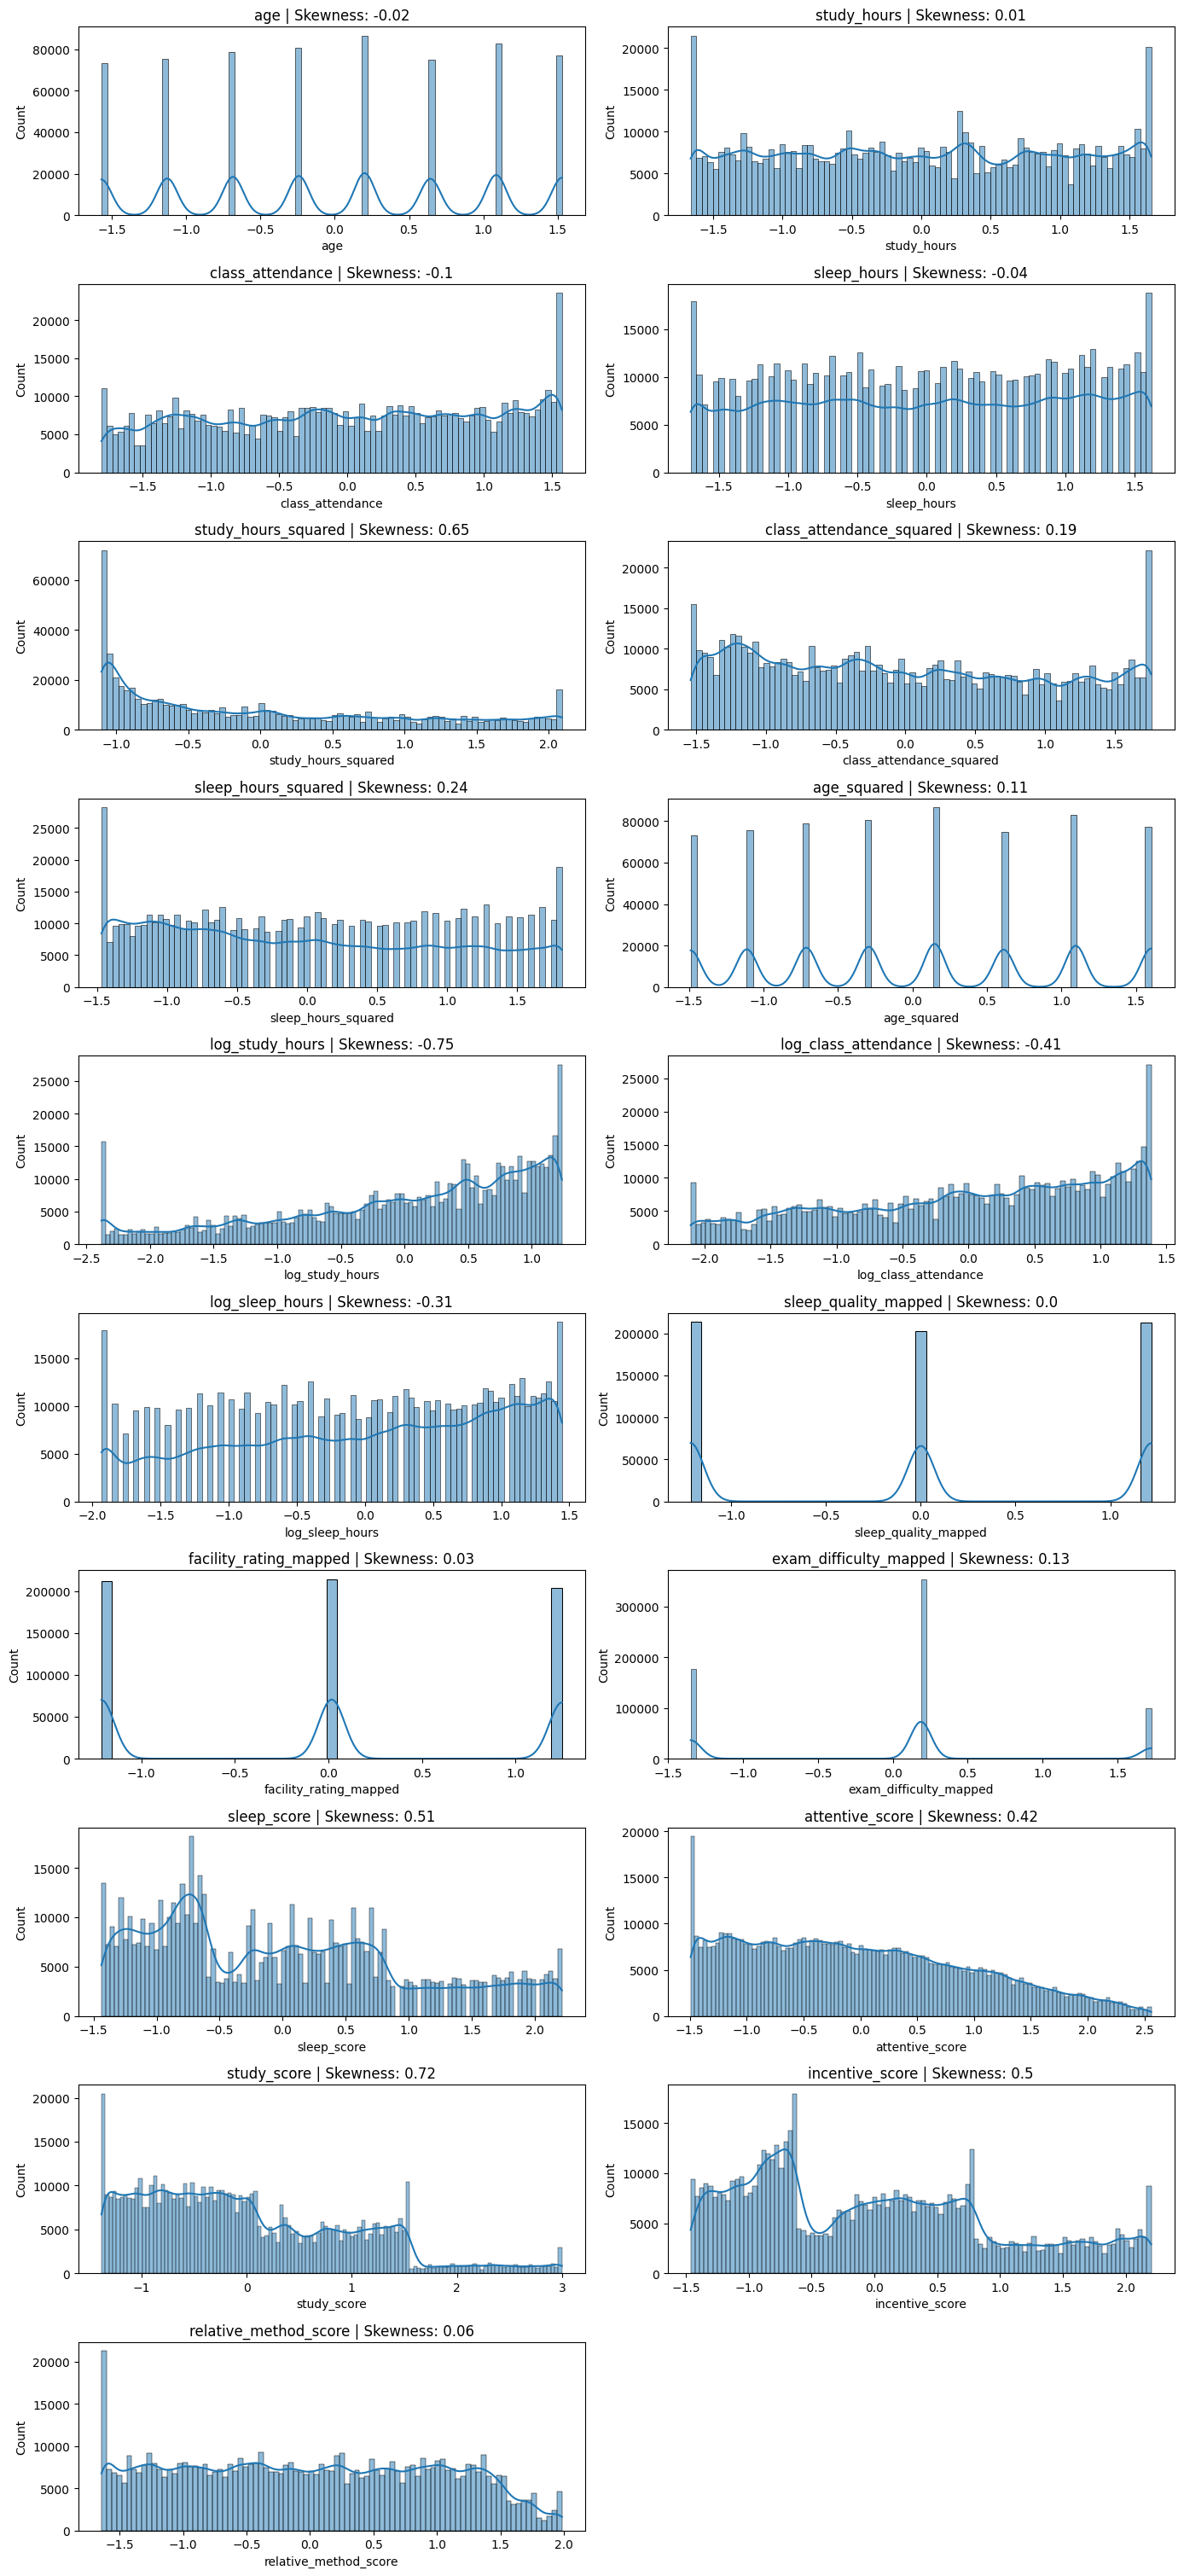

In [28]:
plt.figure(figsize=(14, len(num_cols) * 3))
for idx, feature in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 2, idx)
    sns.histplot(X_train_df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(X_train_df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

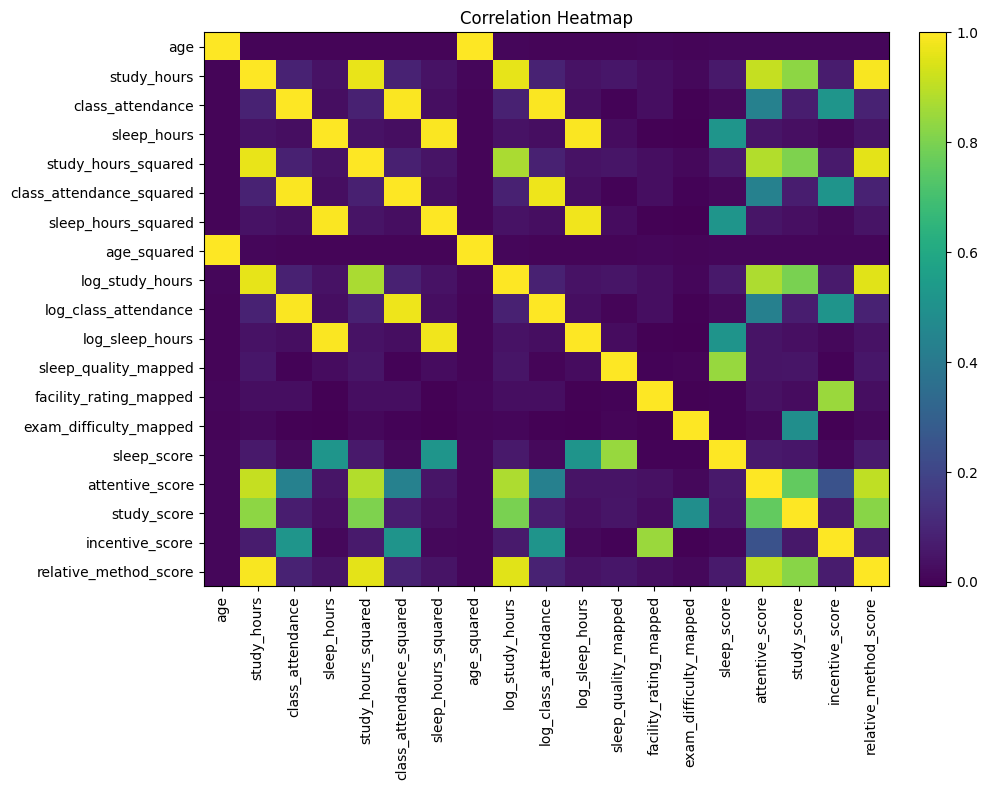

In [29]:
corr_list = ['age', 'study_hours','class_attendance',
 'sleep_hours', 'study_hours_squared', 'class_attendance_squared',
 'sleep_hours_squared', 'age_squared', 'log_study_hours', 'log_class_attendance',
 'log_sleep_hours', 'sleep_quality_mapped', 'facility_rating_mapped',
 'exam_difficulty_mapped', 'sleep_score', 'attentive_score', 'study_score', 
 'incentive_score','relative_method_score',
]
x_corr_df = X_train_df[corr_list]
corr = x_corr_df.corr()

plt.figure(figsize=(10,8))
im = plt.imshow(corr, aspect='auto')

plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()


In [30]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X_train_df, target, test_size=0.1, random_state=42)


In [70]:
import xgboost as xgb

model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=500, learning_rate=0.1)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [71]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)


RMSE: 8.717359729018318


In [ ]:
# RMSE for LR :  8.85766618419121
# RMSE for AdaboostRegressor (AdaBoostRegressor DecisionTreeRegressor(max_depth=4),n_estimators= 100,learning_rate= 0.1,random_state=42) :  9.64715885235059
# RMSE for Elasticnet : 9.03 on L1 ratio 0.5
# RMSE for Elasticnet : 8.966324844814018 on L1 ratio 0.9 better on l1 regularization
# RMSE for Elasticnet :  8.868383483431861 on L1 ratio 0.9 better on l1 regularization and alpha 0.01
# RMSE for Linear SVR :  8.861400606518657 LinearSVR(C=1.0, epsilon=0.2, dual='auto', random_state=42)
# RMSE for XGboostR : 8.717359729018318 objective='reg:squarederror', n_estimators=500, learning_rate=0.1)
# RMSE for LightGBMR : 8.71927107833136 (n_estimators=1000, learning_rate=0.1)
# RMSE for Gradient Boosting :  8.780115689418714 (n_estimators=200, learning_rate=0.1,max_depth=4,random_state=42)
# RMSE for Gradient Boosting :  8.752981114988964 (n_estimators=200, learning_rate=0.2,max_depth=4,random_state=42)
# RMSE for Gradient Boosting :  8.741887925043912 (n_estimators=200, learning_rate=0.5,max_depth=4,random_state=42)


In [72]:
df_test = pd.read_csv("test.csv")

In [73]:
base_features = ['id', 'age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'study_method']


def feature_extraction_test(df_test):
    df_copy = df_test.copy()
    
    sleep_quality_map = {
        'poor' : 1,
        'average' : 2,
        'good':3
        }
    facility_rating_map = {
        'low' : 1,
        'medium' : 2,
        'high' : 3
    }
    exam_difficulty_map = {
        'easy' : 1,
        'moderate' : 2,
        'hard' : 3
    }
    df_copy['sleep_quality_mapped'] = df_copy['sleep_quality'].map(sleep_quality_map).fillna(1).astype(int)
    df_copy['facility_rating_mapped'] = df_copy['facility_rating'].map(facility_rating_map).fillna(1).astype(int)
    df_copy['exam_difficulty_mapped'] = df_copy['exam_difficulty'].map(exam_difficulty_map).fillna(1).astype(int)

    # Sleeping Score sleep_hours * sleep_quality
    df_copy['sleep_score'] = df_copy['sleep_hours'] * df_copy['sleep_quality_mapped']
    # Study Score study_hours * exam_difficulty
    df_copy['study_score'] = df_copy['study_hours'] * df_copy['exam_difficulty_mapped']
    # Incentive Score class_attendance * facility rating
    df_copy['incentive_score'] = df_copy['class_attendance'] * df_copy['facility_rating_mapped']
    # Attentive Score class_attendance * study hours
    df_copy['attentive_score'] = df_copy['class_attendance'] * df_copy['study_hours']

    # Some Polynomial Features
    df_copy['study_hours_squared'] = df_copy['study_hours'] ** 2
    df_copy['class_attendance_squared'] = df_copy['class_attendance'] ** 2
    df_copy['sleep_hours_squared'] = df_copy['sleep_hours'] ** 2
    df_copy['age_squared'] = df_copy['age'] ** 2

    # Some Log features
    df_copy['log_study_hours'] = np.log1p(df_copy['study_hours'])
    df_copy['log_class_attendance'] = np.log1p(df_copy['class_attendance'])
    df_copy['log_sleep_hours'] = np.log1p(df_copy['sleep_hours'])

    # Study Method(weighted by score) vs Study hours 
    method_performance = df.groupby('study_method')['exam_score'].mean()
    global_avg = df['exam_score'].mean()
    method_weights = method_performance / global_avg
    df_copy['relative_method_score'] = df_copy['study_method'].map(method_weights) * df_copy['study_hours']



    numeric_features = [
        'study_hours_squared','class_attendance_squared', 'sleep_hours_squared', 'age_squared',
        'log_study_hours', 'log_class_attendance', 'log_sleep_hours',
        'sleep_quality_mapped', 'facility_rating_mapped', 'exam_difficulty_mapped',
        'sleep_score','attentive_score','study_score','incentive_score','relative_method_score']
    
    return df_copy[base_features + numeric_features]

In [74]:
test_x_df = feature_extraction_test(df_test)
test_x_df.shape

(270000, 24)

In [75]:
num_cols = test_x_df.select_dtypes(include="number").columns.tolist()
cat_cols = test_x_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

test_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop='first', handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

test_x = test_preprocessor.fit_transform(test_x_df)

In [76]:
test_feature_names = test_preprocessor.get_feature_names_out()
X_test_df = pd.DataFrame(test_x, columns=test_feature_names, index=df_test.index)
X_test_df = X_test_df.drop(columns=['id'])
X_test_df.shape

(270000, 32)

In [77]:
id_col = df_test['id']

y_pred_test = model.predict(X_test_df)

out_df = pd.DataFrame({
    "id": id_col,
    "exam_score": y_pred_test
})

out_df.to_csv("submissions.csv", index=False)

